In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')
import pandas as pd
df = pd.read_csv('Lab 21 House_Rent_Dataset.csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [5]:
df.isnull().sum()

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


In [6]:
# chcek for duplicate values and drop it
dup_values = df.duplicated().sum()
dup_values

np.int64(0)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')

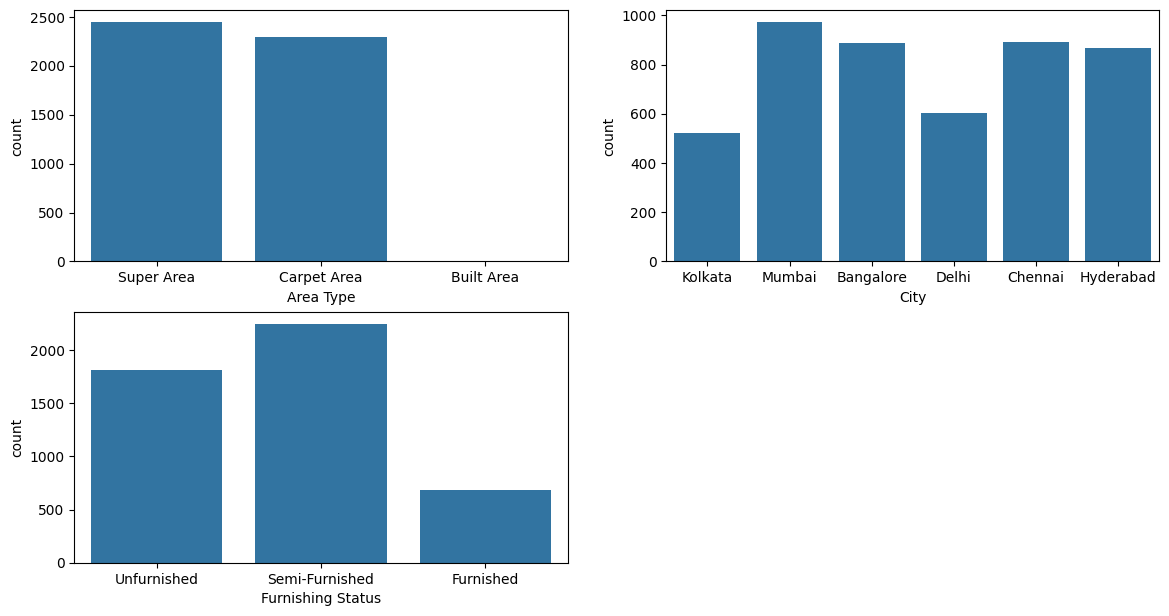

In [8]:
#visualizing the counts of values of objects cols by plotting

plt.figure(figsize=(14,15))
for i,col in enumerate(["Area Type","City","Furnishing Status"]):
    plt.subplot(4,2,i+1)
    sns.countplot(data=df,x=col)

Text(0.5, 1.0, 'Relation betn REnt and BHK by City')

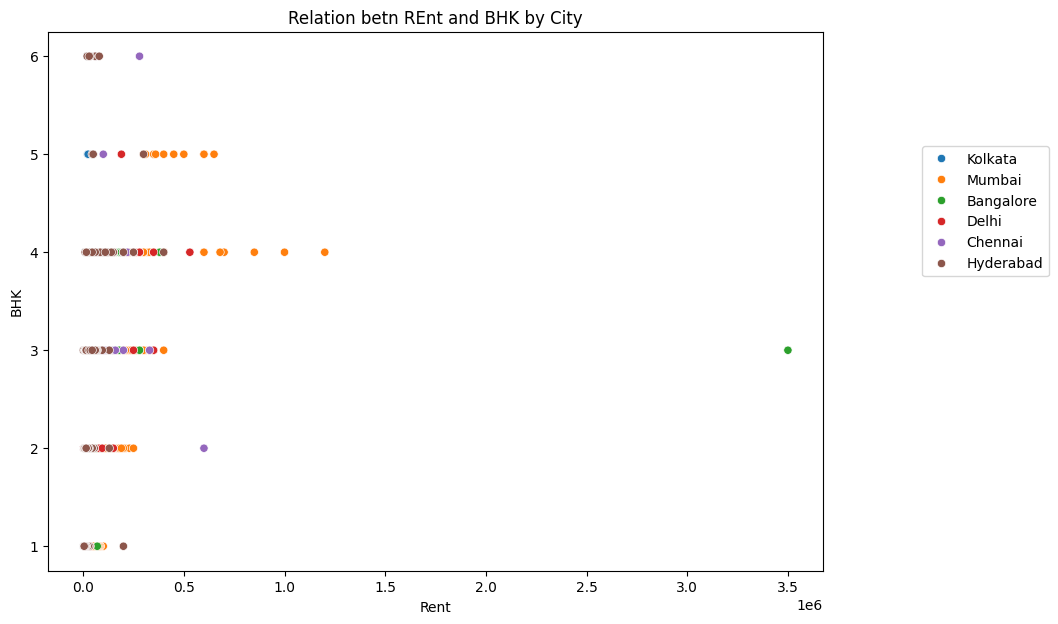

In [9]:
# analyzing relation of rent with bhk

plt.figure(figsize=(10,7))
sns.scatterplot(x='Rent',y='BHK', data = df, hue = "City")
# hue is used for colors by categories

plt.legend(bbox_to_anchor=(1.3,0.8))
plt.title("Relation betn REnt and BHK by City")


<Axes: xlabel='Rent', ylabel='Size'>

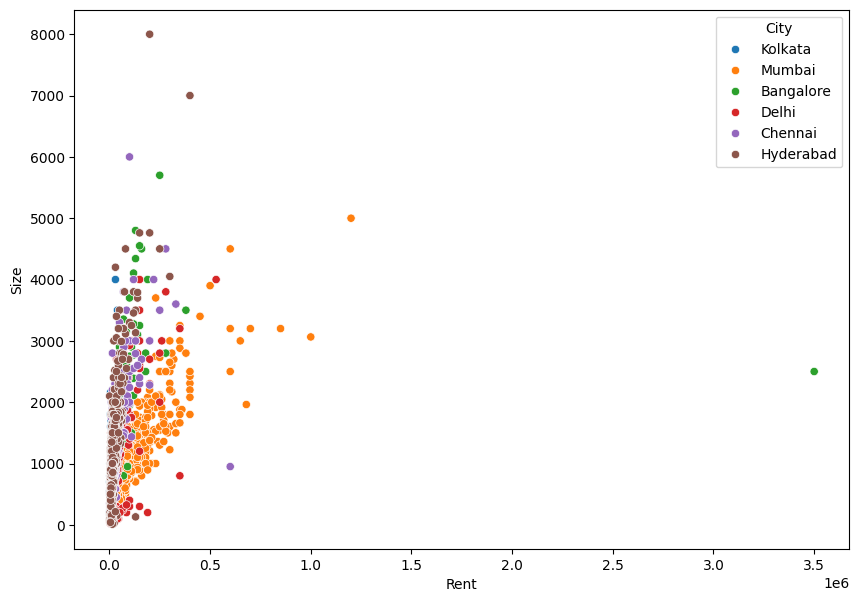

In [10]:
# relation betn rent and size
plt.figure(figsize=(10,7))
sns.scatterplot(data=df,x = 'Rent',y='Size', hue='City')


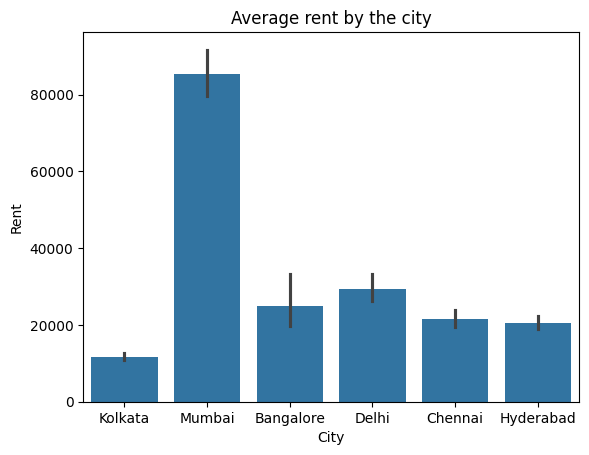

In [11]:
sns.barplot(data = df,x = 'City',y='Rent')
plt.title('Average rent by the city')
plt.show()

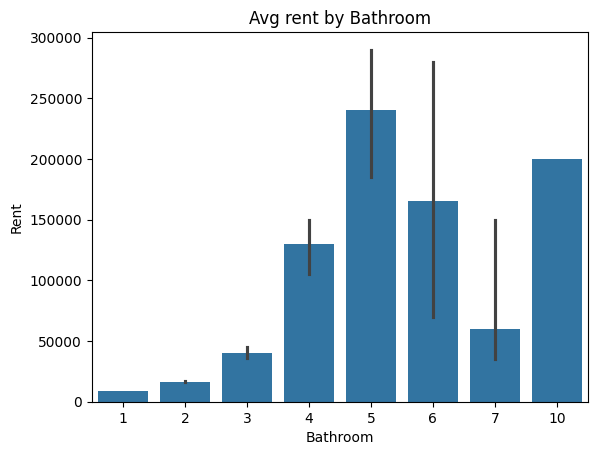

In [12]:
sns.barplot(data = df, x='Bathroom',y='Rent', estimator = np.median)
plt.title('Avg rent by Bathroom')
plt.show()

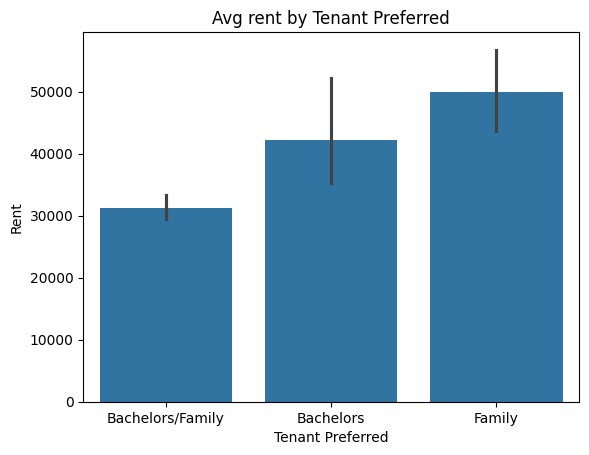

In [13]:
sns.barplot(data = df, x='Tenant Preferred',y='Rent')
plt.title('Avg rent by Tenant Preferred')  # tenant means kiraydar
plt.show()

In [14]:
!pip install category_encoders
!pip install xgboost
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.svm import SVR
import sklearn.metrics as metrics
import xgboost as xgb
import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.3 MB/s eta 0:00:00


### Feature Encoding

>> to convert categorical features into numeric feature

#### Techniques for encoding
>> 1. by replacing values manually  # use when no. of category cols are less

>> 2. by labelencoding

>> 3. by one hot encoding # creates new cols of each value and marks that value and marks that value as 1 and rest as 0
                           in that particular feature , increases the dimension of data

>> 4. category encoder  # encode the categories by numbers



#### Feature scaling

>> to convert all numeric cols in same range

1. MinMaxScaler >> scale between 0 to 1
2. Standardscaler >> scale all data betn -3 to 3


In [15]:
# creating function for evaluation by using error and score
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance = metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    # mean_squared_log_error = metrics.squared_log_error(y_true, y_pred)
    median_absolute_error = metrics.median_absolute_error(y_true, y_pred)
    r2 = metrics.r2_score(y_true, y_pred)


    print('explained_variance:' , round(explained_variance, 4))
    # print('mean_squared_log_error:', round(mean_squared_log_error,4))
    print('r2:' ,round(r2,4))
    print('MAE:', round(mean_absolute_error,4))
    print('RMSE:', round(np.sqrt(mse),4))
    print('Median Absolute Error:',round(median_absolute_error,4))

In [16]:
# separate category cols
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Point of Contact'],
      dtype='object')

In [17]:
for col in categorical_cols:
    print(f"{col}:{df[col].nunique()}")

Posted On:81
Floor:480
Area Type:3
Area Locality:2235
City:6
Furnishing Status:3
Tenant Preferred:3
Point of Contact:3


In [18]:
# dividing input and output feature
x = df.drop(columns = "Rent")
y = df["Rent"]

In [19]:
!pip install category_encoders
# encoding category features
encoder = ce.LeaveOneOutEncoder(return_df = True)
x = encoder.fit_transform(x,y)

In [20]:
# feature scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

In [21]:
# converting the output of above in

x_df = pd.DataFrame(x)
x_df

,0,1,2,3,4,5,6,7,8,9,10
0,0.455100,0.2,0.136421,0.011747,0.273162,0.005055,0.004388,0.009553,0.017960,0.111111,0.003219
1,0.270592,0.2,0.098874,0.017362,0.273074,0.001685,0.004130,0.487075,0.017809,0.000000,0.003165
2,0.146087,0.2,0.123905,0.017377,0.273100,0.024264,0.004207,0.487114,0.017854,0.000000,0.003181
3,0.300748,0.2,0.098874,0.012183,0.273162,0.022466,0.004388,0.009553,0.017960,0.000000,0.003219
4,0.076140,0.2,0.105131,0.012193,0.999941,0.037062,0.004452,0.009593,0.587919,0.000000,0.003233
...,...,...,...,...,...,...,...,...,...,...,...
4741,0.454339,0.2,0.123905,0.023746,0.999871,0.016288,0.124704,0.487140,0.017884,0.111111,0.003192
4742,0.069530,0.4,0.249061,0.028006,0.272994,0.037062,0.124486,0.486957,0.017673,0.222222,0.003116
4743,0.352491,0.4,0.217772,0.023389,0.999683,0.031453,0.124392,0.486879,0.017582,0.222222,0.999656
4744,0.433114,0.4,0.186483,0.042662,0.999589,0.046999,0.124236,0.486748,0.995587,0.111111,0.999541


In [22]:
# dividing data into training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 40)

In [23]:
x_train.shape, x_test.shape

((3796, 11), (950, 11))

## Training models and evaluating each model

In [26]:
model_rfr = RandomForestRegressor(n_estimators = 7)
model_dt = DecisionTreeRegressor()
model_lr = LinearRegression()
model_xgb = xgb.XGBRegressor(objective = 'reg:squarederror')
models = [model_rfr, model_dt, model_lr, model_xgb]

In [27]:
for model in models:
    print(f"fitting model: {model}")
    model.fit(x_train, y_train)

fitting model: RandomForestRegressor(n_estimators=7)
fitting model: DecisionTreeRegressor()
fitting model: LinearRegression()
fitting model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


In [28]:
for model in models:
    print(f"score of {model} for training data: {model.score(x_train, y_train)}")

score of RandomForestRegressor(n_estimators=7) for training data: 0.9231446027714237
score of DecisionTreeRegressor() for training data: 1.0
score of LinearRegression() for training data: 0.31351494675021996
score of XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) for training data: 0.999981105327

## **for error finding**

In [29]:
for model in models[:]:
    y_predicted = model.predict(x_test)

    print(f"Report:{model}")
    print(f"{regression_results(y_test, y_predicted)}\n")

Report:RandomForestRegressor(n_estimators=7)
explained_variance: 0.8537
r2: 0.8537
MAE: 1586.7474
RMSE: 21984.0094
Median Absolute Error: 0.0
None

Report:DecisionTreeRegressor()
explained_variance: 0.9269
r2: 0.9269
MAE: 1017.9432
RMSE: 15535.1083
Median Absolute Error: 0.0
None

Report:LinearRegression()
explained_variance: 0.4874
r2: 0.486
MAE: 20646.2081
RMSE: 41205.4654
Median Absolute Error: 15596.0986
None

Report:XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=No